In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
Loan=pd.read_csv("loan_risk_dataset.csv")
Loan

,Customer_ID,Age,Gender,Income,Employment_Status,Loan_Amount,Loan_Term,Credit_Score,Previous_Default,Loan_Purpose,Monthly_Installment,Defaulted
0,1001,59,Male,82711,Employed,1437682,24,408,Yes,Car,59903.42,Yes
1,1002,49,Male,317683,Employed,1176871,12,445,Yes,Car,98072.58,Yes
2,1003,35,Male,234423,Unemployed,1162383,36,410,No,Business,32288.42,Yes
3,1004,28,Female,229426,Employed,2354656,6,527,No,Business,392442.67,Yes
4,1005,41,Female,438207,Employed,2149365,60,410,No,Personal,35822.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...
145,1146,59,Male,176141,Self-Employed,1286887,6,601,No,Business,214481.17,No
146,1147,53,Female,231372,Employed,2998073,36,662,No,Personal,83279.81,No
147,1148,21,Female,334821,Unemployed,608153,12,695,No,Education,50679.42,No
148,1149,47,Male,105609,Self-Employed,2783317,24,517,No,Car,115971.54,No


### Task 1 Question 1

In [3]:
print(Loan.isnull().sum())


Customer_ID            0
Age                    0
Gender                 0
Income                 0
Employment_Status      0
Loan_Amount            0
Loan_Term              0
Credit_Score           0
Previous_Default       0
Loan_Purpose           0
Monthly_Installment    0
Defaulted              0
dtype: int64


### Task 1 Question 2

In [4]:
Loan.duplicated().sum()




np.int64(0)

### Task 1 Question 3

In [5]:
Loan["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
Loan["Gender"].value_counts()

Gender
Female    77
Male      73
Name: count, dtype: int64

## Task 1 Question 4

In [2]:
Loan.dtypes

Customer_ID              int64
Age                      int64
Gender                  object
Income                   int64
Employment_Status       object
Loan_Amount              int64
Loan_Term                int64
Credit_Score             int64
Previous_Default        object
Loan_Purpose            object
Monthly_Installment    float64
Defaulted               object
dtype: object

### Task 2 Question 1

In [7]:
print("Average Loan Amount",Loan["Loan_Amount"].mean())

Average Loan Amount 1454060.16


### Task 2 Question 2

In [8]:
Loan.groupby('Employment_Status')['Loan_Amount'].mean().sort_values(ascending=False)

Employment_Status
Self-Employed    1.538741e+06
Employed         1.467818e+06
Unemployed       1.265299e+06
Name: Loan_Amount, dtype: float64

### Task 2 Question 3

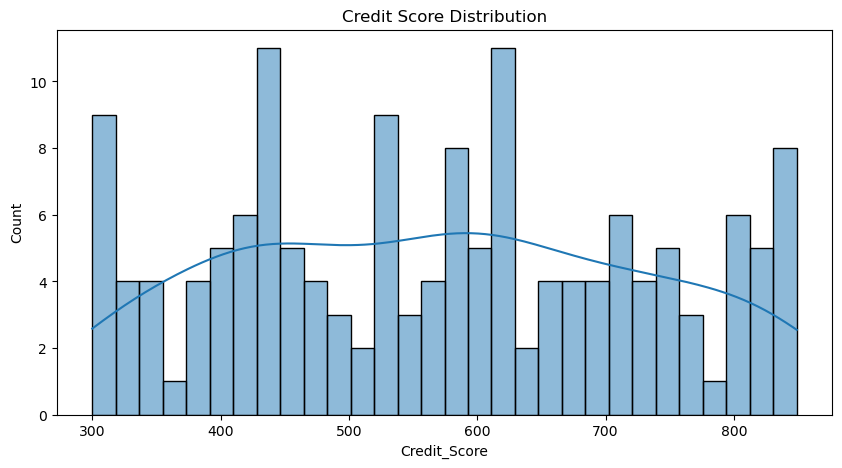

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(Loan['Credit_Score'], bins=30, kde=True)
plt.title('Credit Score Distribution')
plt.show()

### Task 2 Question 4

In [10]:
Loan['Loan_Purpose'].value_counts()


Loan_Purpose
Car          44
Education    39
Business     36
Personal     31
Name: count, dtype: int64

### Task 3 Question 1

In [11]:
bins = [300, 499, 649, 850]
labels = ['Low', 'Medium', 'High']

Loan['Credit_Group'] = pd.cut(Loan['Credit_Score'], bins=bins, labels=labels)

In [12]:
Loan['Defaulted']=Loan['Defaulted'].map({'Yes':1,'No':0})

In [13]:
credit_risk = Loan.groupby('Credit_Group')['Defaulted'].mean() * 100
print(credit_risk)


Credit_Group
Low       61.818182
Medium    38.297872
High      36.170213
Name: Defaulted, dtype: float64


C:\Users\NEW USER\AppData\Local\Temp\ipykernel_13168\2325429181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_risk = Loan.groupby('Credit_Group')['Defaulted'].mean() * 100


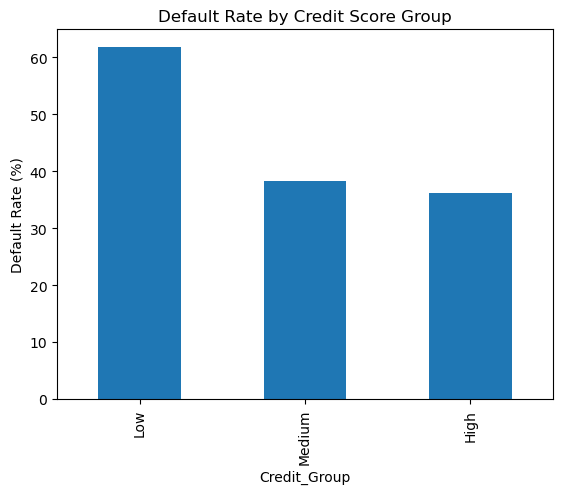

In [14]:
credit_risk.plot(kind='bar')
plt.title('Default Rate by Credit Score Group')
plt.ylabel('Default Rate (%)')
plt.show()

### Task 3 Question 2

In [16]:
previous_default_risk = Loan.groupby('Previous_Default')['Defaulted'].mean() * 100
print(previous_default_risk)

Previous_Default
No     40.322581
Yes    76.923077
Name: Defaulted, dtype: float64


In [20]:
loan_amount_risk = Loan.groupby('Defaulted')['Loan_Amount'].mean()
print(loan_amount_risk)

Defaulted
0    1.443136e+06
1    1.466545e+06
Name: Loan_Amount, dtype: float64


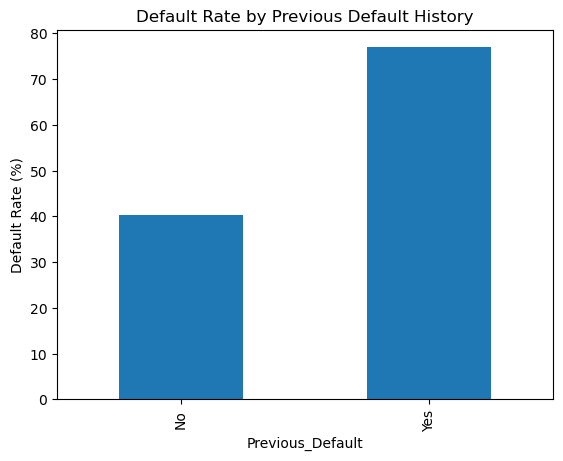

In [17]:
previous_default_risk.plot(kind='bar')
plt.title('Default Rate by Previous Default History')
plt.ylabel('Default Rate (%)')
plt.show()

### Task 3 Question 3

In [15]:
correlation = Loan[['Income', 'Defaulted']].corr()
print(correlation)

             Income  Defaulted
Income     1.000000  -0.075036
Defaulted -0.075036   1.000000


### Task 3 Question 4

In [18]:
employment_risk = Loan.groupby('Employment_Status')['Defaulted'].mean() * 100
print(employment_risk)

Employment_Status
Employed         46.666667
Self-Employed    41.666667
Unemployed       55.555556
Name: Defaulted, dtype: float64


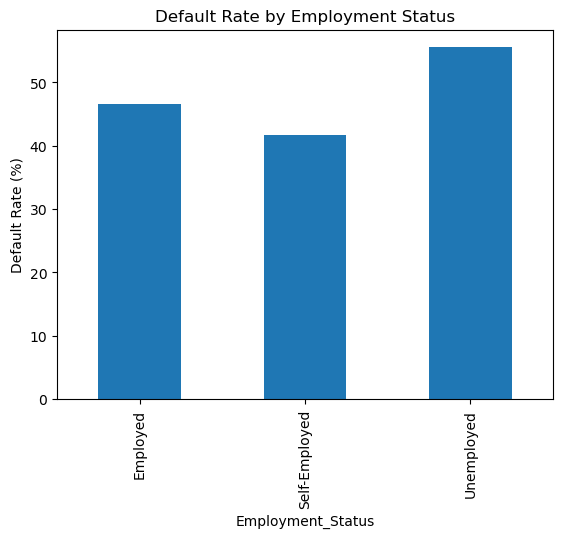

In [19]:
employment_risk.plot(kind='bar')
plt.title('Default Rate by Employment Status')
plt.ylabel('Default Rate (%)')
plt.show()

### Task 4 Question 1

In [21]:
median_income = Loan['Income'].median()

def risk_category(row):
    if row['Credit_Score'] > 600:
        return 'Low Risk'
    elif row['Credit_Score'] < 500 or row['Previous_Default'] == 1 :
        return 'High Risk'
    else:
        return 'Medium Risk'

Loan['Risk_Category'] = Loan.apply(risk_category, axis=1)
Loan['Risk_Category'].value_counts()

Risk_Category
Low Risk       64
High Risk      56
Medium Risk    30
Name: count, dtype: int64

Text(0, 0.5, 'Customer Count')

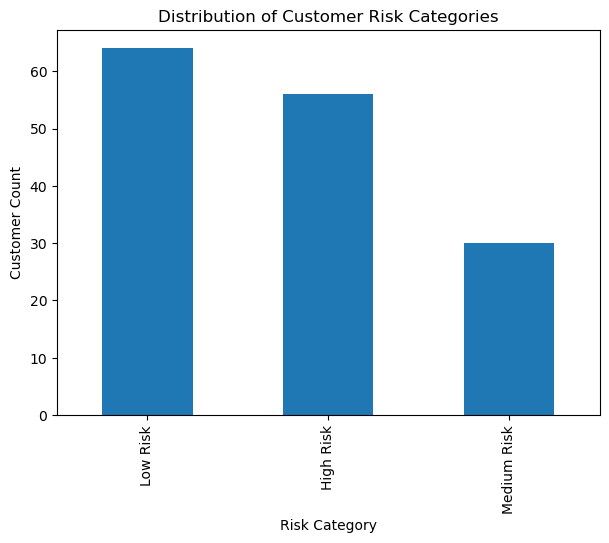

In [22]:
risk_counts = Loan['Risk_Category'].value_counts()
plt.figure(figsize=(7,5))
risk_counts.plot(kind='bar')
plt.title('Distribution of Customer Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Customer Count')




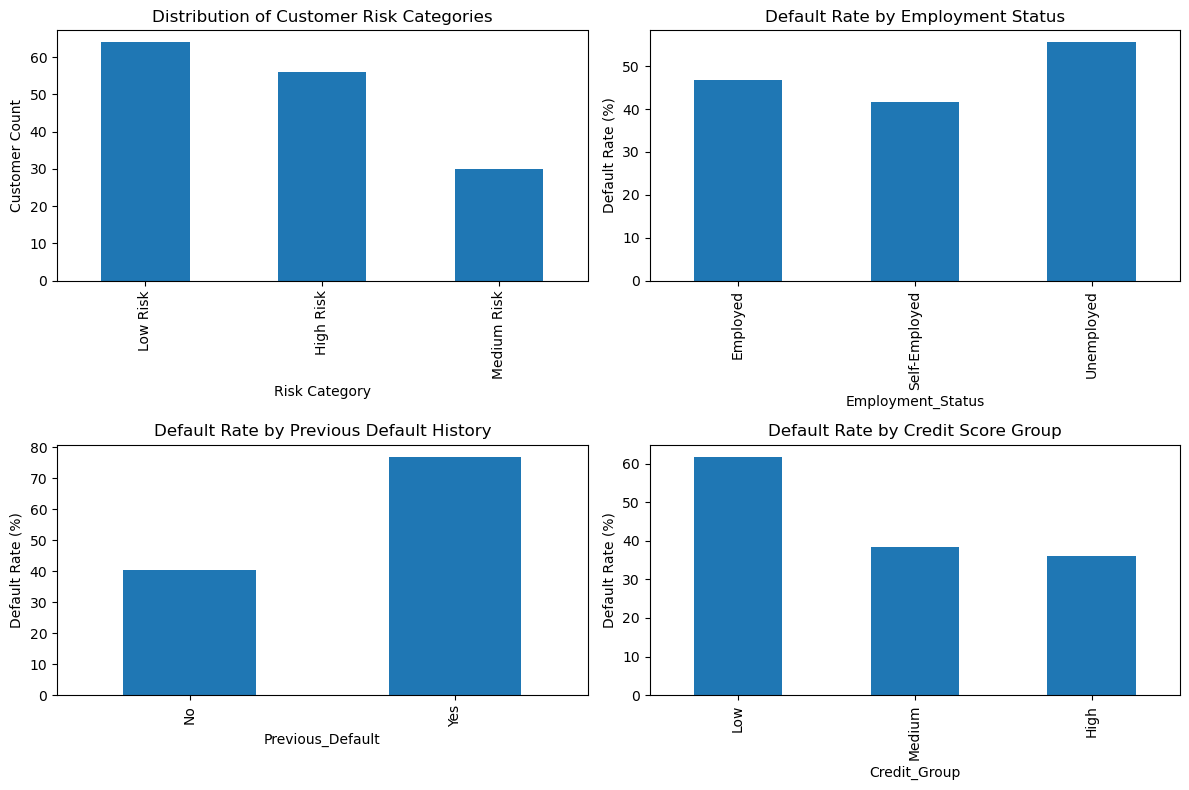

In [26]:


plt.ylabel('Default Rate (%)')plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
risk_counts.plot(kind='bar')
plt.title('Distribution of Customer Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Customer Count')

plt.subplot(2,2,2)

employment_risk.plot(kind='bar')
plt.title('Default Rate by Employment Status')
plt.ylabel('Default Rate (%)')


plt.subplot(2,2,3)

previous_default_risk.plot(kind='bar')
plt.title('Default Rate by Previous Default History')
plt.ylabel('Default Rate (%)')

plt.subplot(2,2,4)

credit_risk.plot(kind='bar')
plt.title('Default Rate by Credit Score Group')

plt.tight_layout()




